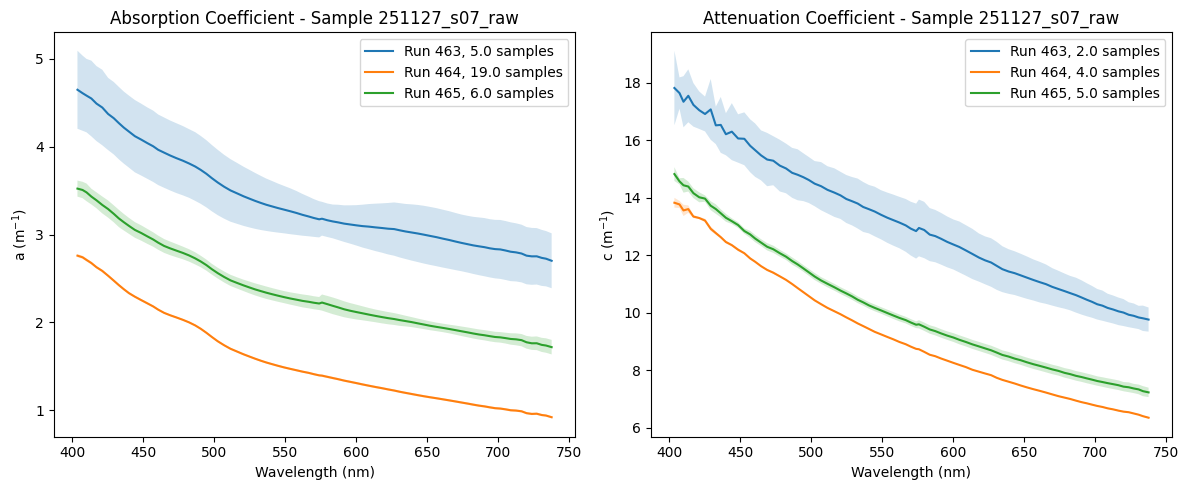

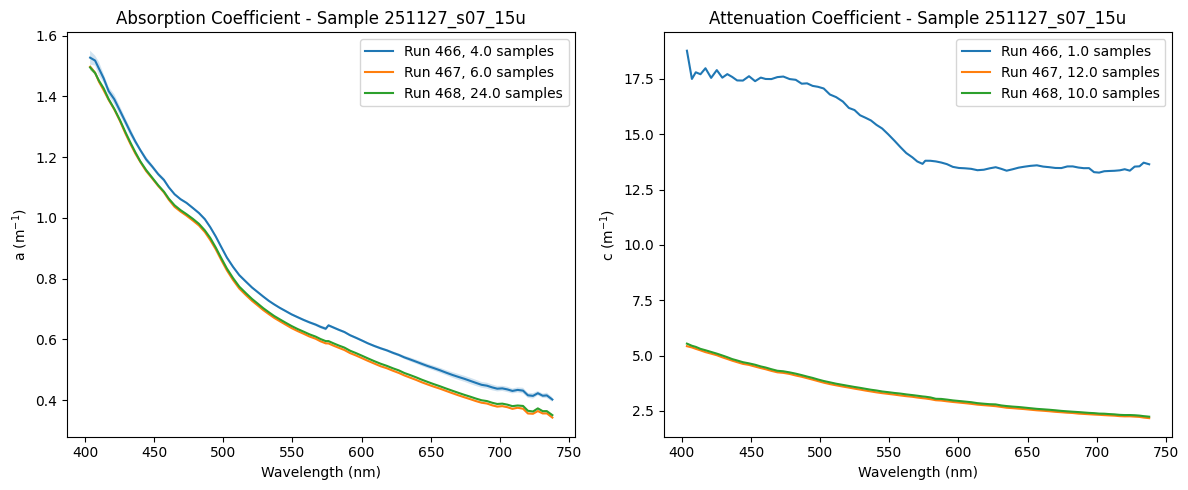

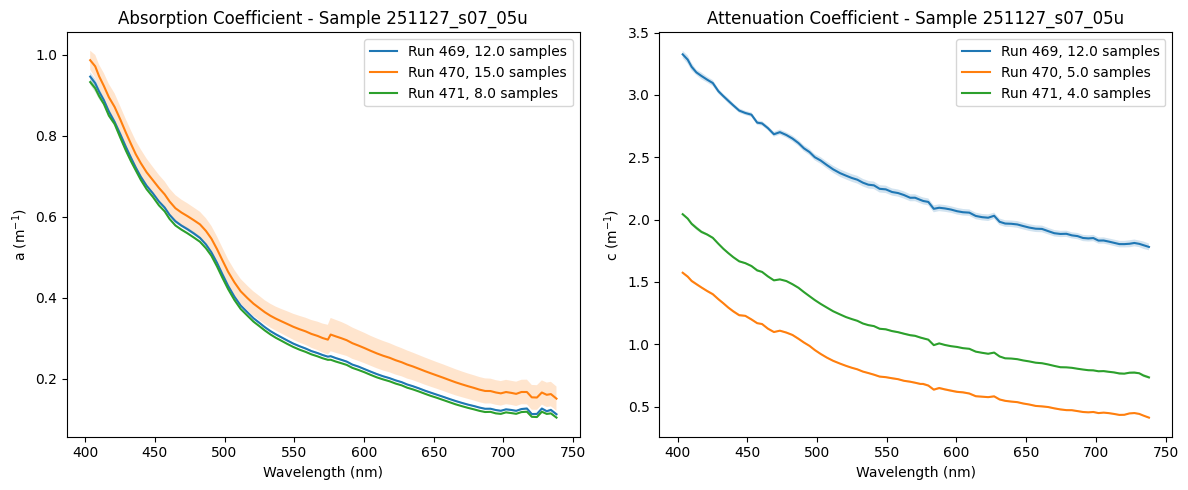

In [10]:
### loading data

import pandas as pd
import matplotlib.pyplot as plt

a_df = pd.read_csv("../2_preprocessed_data/acs_a_extracted_data_advanced.csv", index_col=0)
c_df = pd.read_csv("../2_preprocessed_data/acs_c_extracted_data_advanced.csv", index_col=0)

wv = a_df.columns[3:87].astype(float)

sample = "s07"

sample_list = [
    s for s in a_df["sample"].unique() if sample in s
]



for s in sample_list:
    fig, ax = plt.subplots(ncols=2, figsize=(12,5))
    a_df_s = a_df[a_df["sample"]==s]
    c_df_s = c_df[c_df["sample"]==s]
    for i, row in a_df_s.iterrows():
        ax[0].plot(wv, row[3:87], label=f'Run {row["run_nr"]}, {row["n_valid_spectra"]} samples')
        lower_bound = row[3:87].values - row[87:].values
        upper_bound = row[3:87].values + row[87:].values
        ax[0].fill_between(
            wv, 
            lower_bound.astype("float"), 
            upper_bound.astype("float"), 
            alpha=0.2)
    for i, row in c_df_s.iterrows():
        ax[1].plot(wv, row[3:87], label=f'Run {row["run_nr"]}, {row["n_valid_spectra"]} samples')
        lower_bound = row[3:87].values - row[87:].values
        upper_bound = row[3:87].values + row[87:].values    
        ax[1].fill_between(
            wv, 
            lower_bound.astype("float"), 
            upper_bound.astype("float"), 
            alpha=0.2)

    ax[0].set_title(f'Absorption Coefficient - Sample {s}')
    ax[0].set_xlabel('Wavelength (nm)')
    ax[0].set_ylabel('a (m$^{-1}$)')
    ax[0].legend()
    ax[1].set_title(f'Attenuation Coefficient - Sample {s}')
    ax[1].set_xlabel('Wavelength (nm)')
    ax[1].set_ylabel('c (m$^{-1}$)')
    ax[1].legend()
    plt.tight_layout()
    plt.show()
